In [2]:
import pandas as pd
import numpy as np
from prophet import Prophet
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Load daily sales
daily_sales = pd.read_csv('../data/processed/daily_sales.csv')
daily_sales.columns = ['ds', 'y']

# Ensure ds is datetime
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

# Split data (80% train, 20% test)
train_size = int(len(daily_sales) * 0.8)
train = daily_sales[:train_size]
test = daily_sales[train_size:]

print(f"Train size: {len(train)}, Test size: {len(test)}")

Train size: 591, Test size: 148


In [3]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.05
)

prophet_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

prophet_model.fit(train)

# Make predictions
future = prophet_model.make_future_dataframe(periods=len(test))
forecast = prophet_model.predict(future)

prophet_forecast = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(len(test))

# Calculate Prophet error
prophet_mape = mean_absolute_percentage_error(test['y'], prophet_forecast['yhat'])
print(f"Prophet MAPE: {prophet_mape:.2%}")

23:15:24 - cmdstanpy - INFO - Chain [1] start processing
23:15:24 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAPE: 240038604525057736704.00%


In [4]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out

# Prepare sequences
def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Scale data
scaler_lstm = MinMaxScaler()
scaled_values = scaler_lstm.fit_transform(daily_sales['y'].values.reshape(-1, 1))

# Create sequences
seq_length = 30
X, y = create_sequences(scaled_values, seq_length)

# Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Initialize model
model = LSTMPredictor(input_size=1, hidden_size=64, num_layers=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

# Predict
model.eval()
with torch.no_grad():
    lstm_test_pred = model(X_test_tensor).numpy()

# Inverse transform
lstm_test_pred = scaler_lstm.inverse_transform(lstm_test_pred)
lstm_actual = scaler_lstm.inverse_transform(y_test_tensor.numpy())

lstm_mape = mean_absolute_percentage_error(lstm_actual, lstm_test_pred)
print(f"LSTM MAPE: {lstm_mape:.2%}")


Epoch 20/100, Loss: 0.026124
Epoch 40/100, Loss: 0.025853
Epoch 60/100, Loss: 0.025148
Epoch 80/100, Loss: 0.023437
Epoch 100/100, Loss: 0.021390
LSTM MAPE: 923022089478419251200.00%


In [5]:
# Align predictions
prophet_test = prophet_forecast['yhat'].values[:len(lstm_test_pred)]
ensemble_pred = (prophet_test + lstm_test_pred.flatten()) / 2
ensemble_mape = mean_absolute_percentage_error(lstm_actual, ensemble_pred)
print(f"Ensemble MAPE: {ensemble_mape:.2%}")


Ensemble MAPE: 798396292946188959744.00%


In [6]:
future_30 = prophet_model.make_future_dataframe(periods=30)
forecast_30 = prophet_model.predict(future_30)
prophet_30 = forecast_30[['ds', 'yhat']].tail(30)

# Save forecast
prophet_30.to_csv('../data/processed/30_day_forecast.csv', index=False)

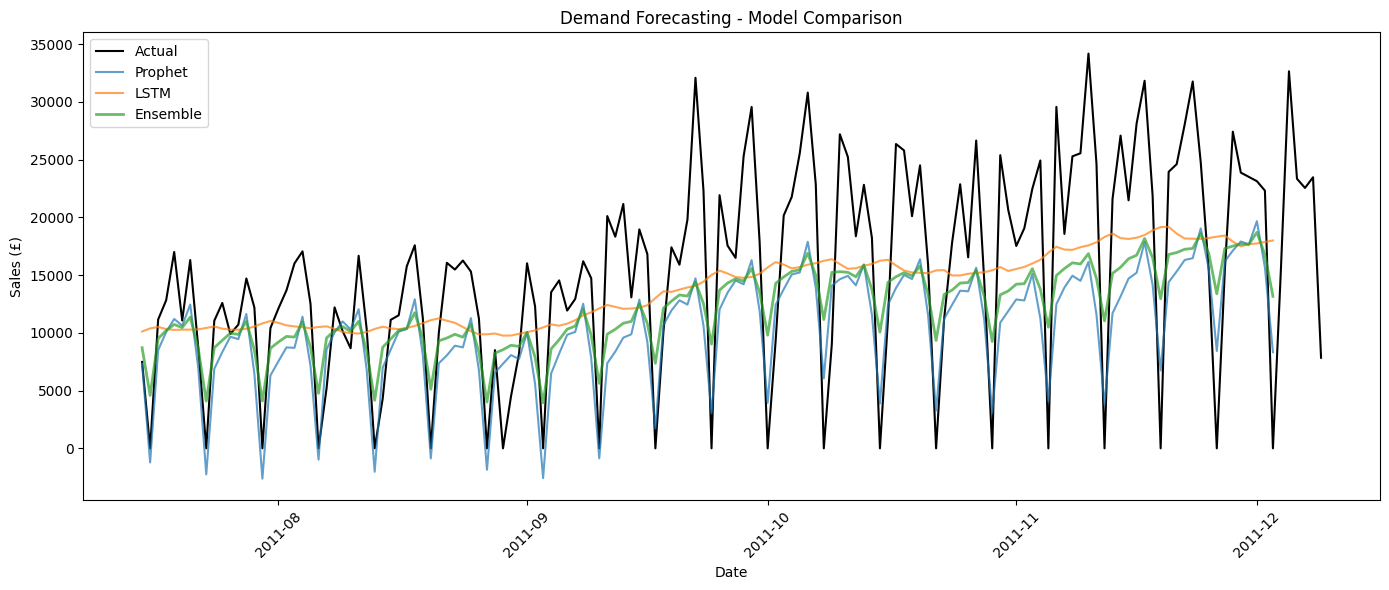

MlflowException: API request to http://localhost:5000/api/2.0/mlflow/runs/create failed with exception HTTPConnectionPool(host='localhost', port=5000): Max retries exceeded with url: /api/2.0/mlflow/runs/create (Caused by NewConnectionError("HTTPConnection(host='localhost', port=5000): Failed to establish a new connection: [Errno 111] Connection refused"))

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(test['ds'], test['y'], label='Actual', color='black')
plt.plot(test['ds'][:len(prophet_test)], prophet_test, label='Prophet', alpha=0.7)
plt.plot(test['ds'][:len(lstm_test_pred)], lstm_test_pred, label='LSTM', alpha=0.7)
plt.plot(test['ds'][:len(ensemble_pred)], ensemble_pred, label='Ensemble', alpha=0.7, linewidth=2)
plt.xlabel('Date')
plt.ylabel('Sales (£)')
plt.title('Demand Forecasting - Model Comparison')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/forecast_comparison.png')
plt.show()

# Save models
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")
with mlflow.start_run(run_name="Demand_Forecasting"):
    mlflow.log_metric("prophet_mape", prophet_mape)
    mlflow.log_metric("lstm_mape", lstm_mape)
    mlflow.log_metric("ensemble_mape", ensemble_mape)
    
    # Save model artifacts
    import joblib
    joblib.dump(prophet_model, '../src/models/prophet_model.pkl')
    torch.save(model.state_dict(), '../src/models/lstm_model.pth')
    joblib.dump(scaler_lstm, '../src/models/lstm_scaler.pkl')